# The Laplace Equation

The Laplace equation is:

$$
\nabla^2 u = 0
$$

or in 2D:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0
$$

## Physical Interpretation

The Laplace equation describes **steady-state conditions** where a quantity $u$ is in equilibrium — it has no sources or sinks and doesn't change with time.

## Common Examples

1. **Temperature distribution**: In a room at thermal equilibrium, the temperature $u(x,y)$ at each point satisfies Laplace's equation.
2. **Electric potential**: The electric potential $u(x,y,z)$ in a charge-free region satisfies Laplace's equation.
3. **Gravitational potential**: In a region with no mass, the gravitational potential satisfies Laplace's equation.
4. **Fluid flow**: The velocity potential in incompressible, irrotational fluid flow satisfies Laplace's equation.
5. **Membrane vibration**: At equilibrium (not vibrating), a membrane's displacement satisfies Laplace's equation.

## Key Idea

At every point, the value $u$ equals the average of its neighbors. If $u$ were higher or lower than the surrounding average, there'd be a source/sink or time-dependence—violating equilibrium.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg
from ipywidgets import IntSlider, interact


def solve_laplace_relaxation(nx=50, ny=50, boundary_val=1.0, n_iter=500):
    """
    Solve Laplace equation on a square grid using Jacobi iteration.
    Boundary conditions: all edges at boundary_val, interior starts at 0.
    """
    u = np.zeros((nx, ny))
    u[0, :] = boundary_val  # top
    u[-1, :] = boundary_val  # bottom
    u[:, 0] = boundary_val  # left
    u[:, -1] = boundary_val  # right
    
    u_new = u.copy()
    
    for _ in range(n_iter):
        u_new[1:-1, 1:-1] = 0.25 * (
            u[:-2, 1:-1] + u[2:, 1:-1] + u[1:-1, :-2] + u[1:-1, 2:]
        )
        u = u_new.copy()
    
    return u

In [4]:
def visualize_laplace(n_iter=100):
    """
    Visualize the solution to Laplace equation on a heated plate.
    Edges are held at temperature 1.0, interior diffuses inward.
    """
    u = solve_laplace_relaxation(nx=80, ny=80, boundary_val=1.0, n_iter=n_iter)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap
    im = axes[0].imshow(u, cmap='hot', origin='lower', extent=[0, 1, 0, 1])
    axes[0].set_title(f"Temperature distribution after {n_iter} iterations")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im, ax=axes[0], label="Temperature")
    
    # Cross-section along y=0.5
    mid_y = u.shape[0] // 2
    axes[1].plot(u[mid_y, :], linewidth=2, color='crimson')
    axes[1].set_title("Temperature profile at y = 0.5")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u(x, 0.5)")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.show()


interact(
    visualize_laplace,
    n_iter=IntSlider(value=100, min=10, max=1000, step=50, description="iterations")
);

interactive(children=(IntSlider(value=100, description='iterations', max=1000, min=10, step=50), Output()), _d…

## Key Observations

- **Boundary-driven**: The solution is completely determined by the values on the boundary. There are no interior sources.
- **Smoothness**: The solution has no sharp peaks or valleys in the interior—it's as "smooth" as possible.
- **Equilibrium**: Each point's value is the average of nearby points. This is the discrete harmonic mean property.
- **Convergence**: The iterative solver gradually diffuses boundary information inward until equilibrium is reached.

## Complex Link: Why `cos(z)` Connects to Laplace

Let `z = x + iy`. Then

$$
\cos(z) = \cos(x+iy) = \cos x\,\cosh y - i\sin x\,\sinh y.
$$

So if `cos(z) = u(x,y) + i v(x,y)`, we get:

- $u(x,y) = cos x * cosh y$
- $v(x,y) = -sin x * sinh y$

Both `u` and `v` satisfy Laplace's equation:

$$
u_{xx} + u_{yy} = 0, \quad v_{xx} + v_{yy} = 0.
$$

That is why `cos(z)` (analytic in the complex plane) gives harmonic real and imaginary parts.

In [11]:
# Numerical check that Re(cos z) and Im(cos z) are harmonic
x = np.linspace(-2.0, 2.0, 201)
y = np.linspace(-2.0, 2.0, 201)
X, Y = np.meshgrid(x, y, indexing='xy')

u = np.cos(X) * np.cosh(Y)          # Re(cos(x+iy))
v = -np.sin(X) * np.sinh(Y)         # Im(cos(x+iy))

dx = x[1] - x[0]
dy = y[1] - y[0]

def laplacian(F, dx, dy):
    Fxx = (F[1:-1, 2:] - 2*F[1:-1, 1:-1] + F[1:-1, :-2]) / dx**2
    Fyy = (F[2:, 1:-1] - 2*F[1:-1, 1:-1] + F[:-2, 1:-1]) / dy**2
    return Fxx + Fyy

Lu = laplacian(u, dx, dy)
Lv = laplacian(v, dx, dy)

print('max |Δu|:', np.max(np.abs(Lu)))
print('max |Δv|:', np.max(np.abs(Lv)))

max |Δu|: 0.00024602707426879533
max |Δv|: 0.00023681242633522004


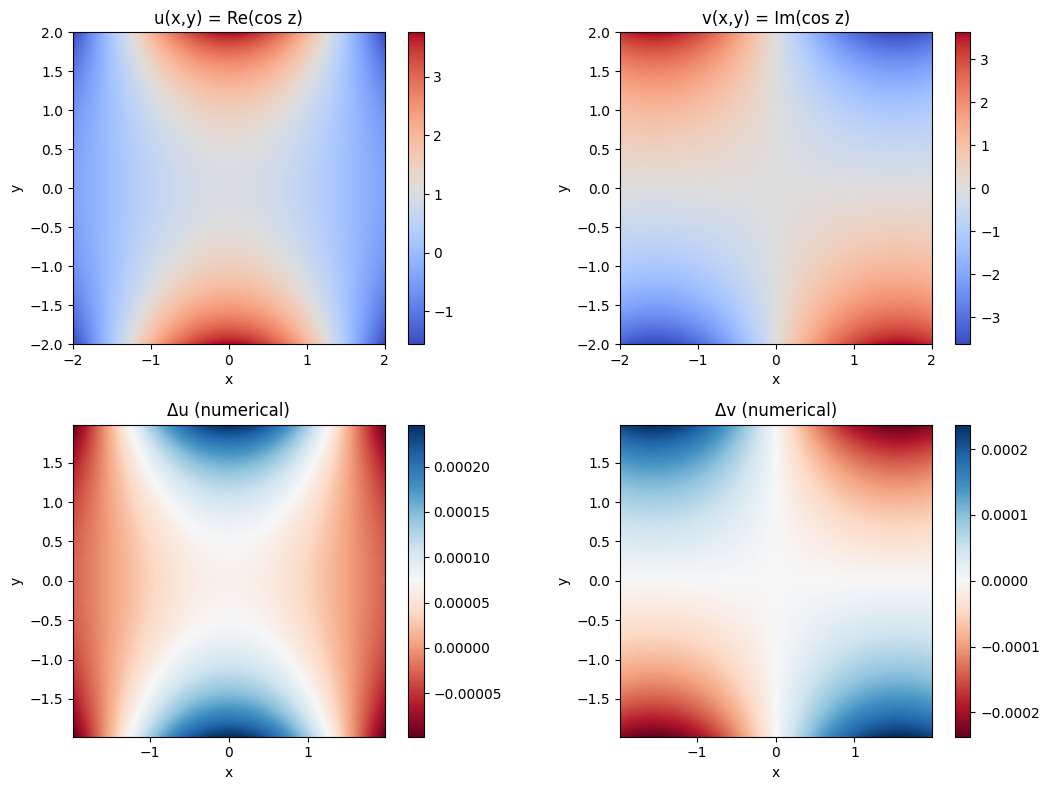

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

im0 = axes[0, 0].imshow(u, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm')
axes[0, 0].set_title('u(x,y) = Re(cos z)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(v, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm')
axes[0, 1].set_title('v(x,y) = Im(cos z)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(Lu, extent=[x[1], x[-2], y[1], y[-2]], origin='lower', cmap='RdBu')
axes[1, 0].set_title('Δu (numerical)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(Lv, extent=[x[1], x[-2], y[1], y[-2]], origin='lower', cmap='RdBu')
axes[1, 1].set_title('Δv (numerical)')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()